In [1]:
# KNN - K nearest neighbour

In [2]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

In [3]:
# dataset
df=pd.read_csv("/content/Cancer_Data.csv")
print(df)

           id diagnosis  ...  fractal_dimension_worst  Unnamed: 32
0      842302         M  ...                  0.11890          NaN
1      842517         M  ...                  0.08902          NaN
2    84300903         M  ...                  0.08758          NaN
3    84348301         M  ...                  0.17300          NaN
4    84358402         M  ...                  0.07678          NaN
..        ...       ...  ...                      ...          ...
564    926424         M  ...                  0.07115          NaN
565    926682         M  ...                  0.06637          NaN
566    926954         M  ...                  0.07820          NaN
567    927241         M  ...                  0.12400          NaN
568     92751         B  ...                  0.07039          NaN

[569 rows x 33 columns]


In [17]:
print(df.isna().sum())


id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

In [18]:
# Forward fill
df = df.ffill()

# Backward fill remaining NaNs (important for first row)
df = df.bfill()
df

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,1.1760,1.2560,7.673,158.70,0.010300,0.02891,0.05198,0.02454,0.01114,0.004239,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,0.7655,2.4630,5.203,99.04,0.005769,0.02423,0.03950,0.01678,0.01898,0.002498,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,0.4564,1.0750,3.425,48.55,0.005903,0.03731,0.04730,0.01557,0.01318,0.003892,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,0.7260,1.5950,5.772,86.22,0.006522,0.06158,0.07117,0.01664,0.02324,0.006185,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN


In [24]:
df = df.drop(columns=["Unnamed: 32"])


In [25]:
print(df.isna().sum())


id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64


In [26]:
X = df.drop(columns=["diagnosis"])   # feature columns(droping the diagnosis and x conatins all the other input features )
y = df["diagnosis"]                  # target column(y conatins the target column that is diagnosis)
y = y.map({"M": 1, "B": 0})          # mapping m to 1 and b to 0 as dataset conatins m and b which cannot be procesed by ml


In [41]:
selected_features = ["radius_mean", "texture_mean"]
X = df[selected_features]
y = df["diagnosis"]


In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y                  # this is used to ensure that the m/b ratio is same in train and test
)

In [43]:
# feature scaling is very important for knn in order to scale evry column in a particular range and to get accurate results
scaler = StandardScaler()
x_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [45]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train, y_train)

KNeighborsClassifier()

In [46]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = knn.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.9122807017543859
              precision    recall  f1-score   support

           0       0.89      0.99      0.93        72
           1       0.97      0.79      0.87        42

    accuracy                           0.91       114
   macro avg       0.93      0.89      0.90       114
weighted avg       0.92      0.91      0.91       114



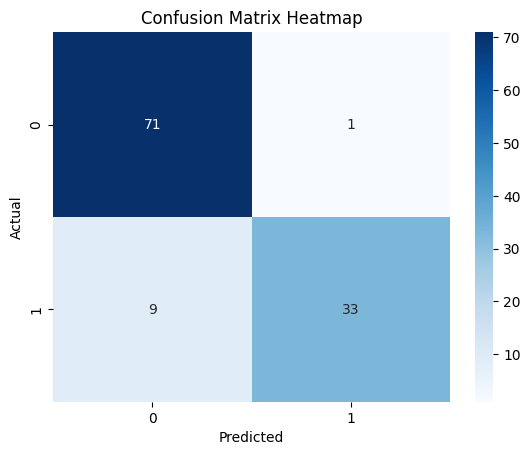

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")   # annot - shows numbers on the heatmap and fmt="d" is integer formatting
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix Heatmap")
plt.show()


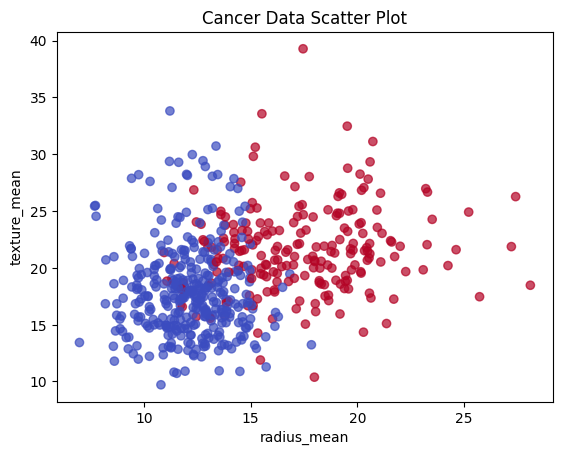

In [48]:
import matplotlib.pyplot as plt

plt.scatter(
    X["radius_mean"],
    X["texture_mean"],
    c=y,                              # colors points based on target class (0 = benign, 1 = malignant).
    cmap="coolwarm",                  # color map that is blue for b and red for m
    alpha=0.7                         # transperncy to make overlap points visible in scatter plot
)

plt.xlabel("radius_mean")
plt.ylabel("texture_mean")
plt.title("Cancer Data Scatter Plot")
plt.show()


In [49]:
from sklearn.metrics import roc_curve, auc

y_prob = knn.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

print("AUC:", roc_auc)


AUC: 0.9361772486772487


In [50]:
print("\nEnter new patient data:")
radius = float(input("radius_mean: "))
texture = float(input("texture_mean: "))

new_point = np.array([[radius, texture]])
new_point_scaled = scaler.transform(new_point)
prediction = knn.predict(new_point_scaled)

if prediction[0] == 0:
    print("Prediction: Benign (0)")
else:
    print("Prediction: Malignant (1)")


Enter new patient data:
radius_mean: 20.01
texture_mean: 39.1
Prediction: Malignant (1)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [51]:
# performing knn without using inbuilt libraries
import pandas as pd
import numpy as np
df = pd.read_csv("/content/Cancer_Data.csv")

# Map target to 0 and 1
df['diagnosis'] = df['diagnosis'].map({'B': 0, 'M': 1})

# Features and target
selected_features = ["radius_mean", "texture_mean"]
X = df[selected_features].values
y = df["diagnosis"].values

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
# Standardize features
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)

X_train_scaled = (X_train - mean) / std
X_test_scaled = (X_test - mean) / std
def euclidean_distance(a, b):
    return np.sqrt(np.sum((a - b) ** 2))

def knn_predict(X_train, y_train, X_test, k=5):
    y_pred = []

    for test_point in X_test:
        # Compute distances to all training points
        distances = [euclidean_distance(test_point, x) for x in X_train]

        # Sort distances and get indices of k nearest neighbors
        k_indices = np.argsort(distances)[:k]

        # Get the labels of k nearest neighbors
        k_labels = [y_train[i] for i in k_indices]

        # Majority vote
        counts = np.bincount(k_labels)  # counts of 0s and 1s
        predicted_label = np.argmax(counts)

        y_pred.append(predicted_label)

    return np.array(y_pred)
k = 5
y_pred = knn_predict(X_train_scaled, y_train, X_test_scaled, k=k)
accuracy = np.mean(y_pred == y_test)
print("Accuracy:", accuracy)
def confusion_matrix_manual(y_true, y_pred):
    TP = np.sum((y_true == 1) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))
    return np.array([[TN, FP],
                     [FN, TP]])

cm = confusion_matrix_manual(y_test, y_pred)
print("Confusion Matrix:\n", cm)

print("\nEnter new patient data:")

radius = float(input("radius_mean: "))
texture = float(input("texture_mean: "))

new_point = np.array([[radius, texture]])
new_point_scaled = (new_point - mean) / std  # scale using training mean/std
prediction_new = knn_predict(X_train_scaled, y_train, new_point_scaled, k=k)

print("Prediction:", "Benign (0)" if prediction_new[0] == 0 else "Malignant (1)")


Accuracy: 0.9122807017543859
Confusion Matrix:
 [[71  1]
 [ 9 33]]

Enter new patient data:
radius_mean: 12
texture_mean: 45
Prediction: Malignant (1)
